In [ ]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm


In [ ]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


In [ ]:
activation_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/activation_dict.pt')
ephys_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/ephys_dict.pt')
spectrogram_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/spectrogram_dict.pt')


In [ ]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
activation_corrcoef = {}
for name in ['AnyNet', 'ViT', 'RNN']:
    activation_m = []
    for acronym in activation_dict[name].keys():
        activation_m.append(activation_dict[name][acronym].unsqueeze(0))
    activation_m = torch.concat(activation_m, dim=0)
    activation_corrcoef[name] = torch.corrcoef(activation_m)

In [ ]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
ephys_corrcoef = {}
for name in ['AnyNet', 'ViT', 'RNN']:
    ephys_m = []
    for acronym in ephys_dict[name].keys():
        ephys_m.append(ephys_dict[name][acronym].unsqueeze(0))
    ephys_m = torch.concat(ephys_m, dim=0)
    ephys_corrcoef[name] = torch.corrcoef(ephys_m)

In [ ]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
spectrogram_corrcoef = {}
for name in ['AnyNet', 'ViT', 'RNN']:
    spectrogram_m = []
    for acronym in spectrogram_dict[name].keys():
        spectrogram_m.append(spectrogram_dict[name][acronym].flatten().unsqueeze(0))
    spectrogram_m = torch.concat(spectrogram_m, dim=0)
    spectrogram_corrcoef[name] = torch.corrcoef(spectrogram_m)

In [ ]:
plt.figure(dpi=200)
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.subplot(1, 3, name_ii + 1)
    plt.imshow(ephys_corrcoef[name].detach().cpu().numpy())
    sns.despine()
    plt.title(name)
    plt.xticks([])
    plt.yticks([])
    if name_ii == 0:
        plt.xlabel('Brain region')
        plt.ylabel('Brain region')
    plt.colorbar(fraction=0.01)
plt.show()

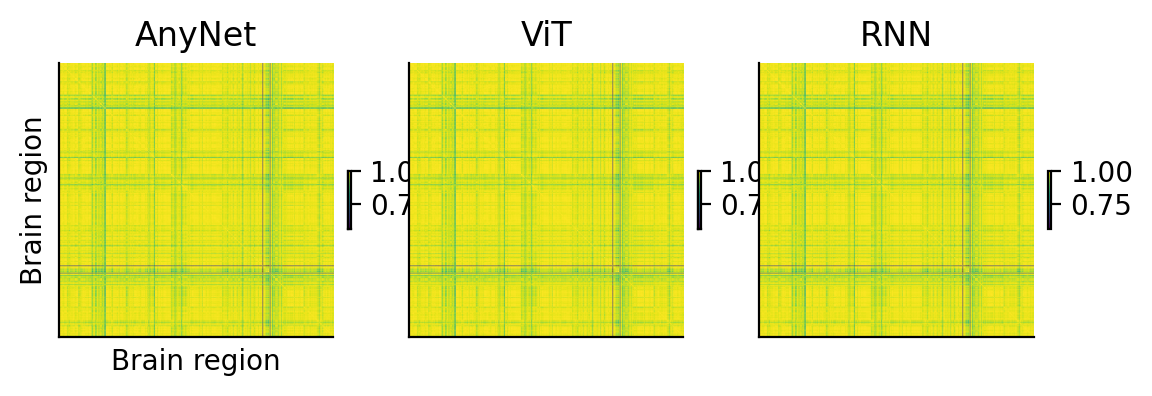

In [ ]:
plt.figure(dpi=200)
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.subplot(1, 3, name_ii + 1)
    plt.imshow(spectrogram_corrcoef[name].detach().cpu().numpy())
    sns.despine()
    plt.title(name)
    plt.xticks([])
    plt.yticks([])
    if name_ii == 0:
        plt.xlabel('Brain region')
        plt.ylabel('Brain region')
    plt.colorbar(fraction=0.01)
plt.show()

In [ ]:
plt.figure(dpi=200)
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.subplot(1, 3, name_ii + 1)
    plt.imshow(activation_corrcoef[name].detach().cpu().numpy())
    sns.despine()
    plt.title(name)
    plt.xticks([])
    plt.yticks([])
    if name_ii == 0:
        plt.xlabel('Brain region')
        plt.ylabel('Brain region')
    plt.colorbar(fraction=0.02)
plt.show()

In [ ]:
# plt.figure(dpi=200)
# for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
#     plt.subplot(1, 3, name_ii + 1)
#     plt.imshow(corrcoef[name].detach().cpu().numpy())
#     sns.despine()
#     plt.title(name)
#     plt.xticks([])
#     plt.yticks([])
#     if name_ii == 0:
#         plt.xlabel('Brain region')
#         plt.ylabel('Brain region')
#     plt.colorbar(fraction=0.02)
# plt.show()

In [ ]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
activation_corrcoef_flatten = []
for name in ['AnyNet', 'ViT', 'RNN']:
    activation_corrcoef_flatten.append(activation_corrcoef[name].flatten().unsqueeze(0))

activation_corrcoef_flatten = torch.concat(activation_corrcoef_flatten, dim=0)
r = torch.corrcoef(activation_corrcoef_flatten)
plt.figure(dpi=200)
sns.heatmap(r.detach().cpu().numpy(), annot=True)
plt.yticks(np.array([0, 1, 2]) + 0.5, Classifier_name)
plt.xticks(np.array([0, 1, 2]) + 0.5, Classifier_name)
sns.despine()